# changeto01


In [ ]:
def changeto01(y_train,y_test):

  a=y_train[0]
  yt_train=[0 if x==a else 1 for x in y_train]
  yt_test=[0 if x==a else 1 for x in y_test]
  return yt_train,yt_test

# EKSL

In [ ]:
from numpy.ma.core import log
import pandas as pd
import csv
import numpy as np
from google.colab import drive
from sklearn.cluster import KMeans
import math
from sklearn import svm
from statistics import mean
from sklearn.linear_model import LogisticRegression

def EKSL(trainX,trainz,testX,C,GAMMA,label=[0,1]):

  nC=len(trainX[0])
  Minority=[];Majority=[]
  for i in range(len(trainX)-1):
    if trainz[i]==label[0]:
      Minority.append(list(trainX[i]))
    else:
      Majority.append(list(trainX[i]))
  #Majority=df[df['Z']==label[1]]
  #X=df.iloc[:,0:nC]
  #Z=df.iloc[:,nC]
  X=trainX
  #Z=trainz
  if(len(Minority)>len(Majority)):
    temp=Minority
    Minority=Majority
    Majority=temp
    tt=label[0]
    label[0]=label[1]
    label[1]=tt
  n_Clusters=math.ceil(len(Majority)/len(Minority))
  kmeans=KMeans(n_clusters=n_Clusters,random_state=0)
  kmeans.fit(Majority)
  Z=[-1  if x==label[0]  else 1 for x in trainz]

  cluster_map = pd.DataFrame()
  cluster_map['cluster'] = kmeans.labels_
  Clusters=[]
  clf=[]
  Maj=[]
  for i in range(n_Clusters):
    indices = [j for j, x in enumerate(list(kmeans.labels_)) if x == i]
    for m in range(len(Majority)-1):
      if m in indices:
        Maj.append(Majority[i])
    Minor=Minority
    Minor=np.concatenate((np.array(Minor),np.array(Maj)))
    train_z=np.concatenate(([-1]*len(Minority),[1]*len(Maj)))

    clf.append(svm.SVC(C=50,kernel="linear"))
    clf[i].fit(Minor,train_z)

#calculate distances
  decisions=[]
  Threshold=[]
  for i in range(n_Clusters):
    y = clf[i].decision_function(X)
    w_norm = np.linalg.norm(clf[i].coef_)
    temp=y / w_norm
    decisions.append(list(temp))

#apply logistic regression
  logCoeff=[]
  Intercept=[0]*n_Clusters
  Coeff=[0]*n_Clusters
  Threshold=0

  for i in range(n_Clusters):
    cl = LogisticRegression(random_state=0).fit(np.array(np.array(decisions[i])).reshape(-1, 1),Z)
    LogCoeff=[cl.intercept_+cl.coef_*x for x in decisions[i]]
    Intercept[i]=cl.intercept_
    Coeff[i]=cl.coef_
    A=list(np.array(LogCoeff).reshape(1,len(decisions[i]))[0])
    Threshold=Threshold+mean(A)
    logCoeff.append(LogCoeff)

  Threshold=Threshold/n_Clusters
  TestVal=[]
  for j in range(n_Clusters):
    y = clf[j].decision_function(testX)
    w_norm = np.linalg.norm(clf[j].coef_)
    temp=y / w_norm
    A=list(np.array(temp).reshape(1,len(testX))[0])
    A=[Intercept[j][0]+Coeff[j][0][0]*x for x in A]
    TestVal.append(A)
  TotalVal=[0]*len(testX)
  for j in range(n_Clusters):
    for k in range(len(testX)):
      TotalVal[k]=TotalVal[k]+TestVal[i][k]
  TotalVal=[x/n_Clusters for x in TotalVal]
  PredictedVal=[1 if x >Threshold else 0 for x in TotalVal]
  return PredictedVal

# dynamic selection for fault classification

In [ ]:

import pandas as pd
import csv
import numpy as np
from google.colab import drive
from sklearn.utils import resample
from sklearn import tree
import random
import math
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from sklearn import svm


def DynamicSelection(XX,Z,testX,C,GAMMA,valLabel=[0,1]):


  N=5
  S=3
  X=[]
  Z=[0  if x==valLabel[0]  else 1 for x in Z]
  for i in range(len(XX)-1):
    A=list(XX[i])
    A.append(Z[i])
    X.append(A)
    #print(X)
  nC=len(X[0])
  ValSet=len(X)/10
  ValidationSet=X[(len(X)-math.floor(ValSet)):]
  ValSet=len(ValidationSet)


#Bootstrap
  boot=[]
  clf=[]
  for i in range(N):
    boot.append(resample(X, replace=True, n_samples=len(X), random_state=1))
    clf.append(svm.SVC(C=C,kernel="rbf",gamma=GAMMA))
  #clf.append(tree.DecisionTreeClassifier())
    clf[i]=clf[i].fit(np.array(boot[i])[:,0:nC-1],np.array(boot[i])[:, nC-1])



  #testZ=[0  if x.replace(' ','')=='negative'  else 1 for x in testz]
  TotalPred=[]
  Weight=[]
  ValidationSet=np.array(ValidationSet)

  for t in testX:
    Dist=[0]*ValSet
    count=0
    for v in ValidationSet:
      eucDist=[0]*len(v)
      for k in range(0,len(v)-1):
        eucDist[k]=(t[k]-v[k])**2
      Dist[count]=math.sqrt(sum(eucDist))
      count=count+1
 #finding k-NN where k=3
    k=3
    Distance=list(Dist)
    kNN=[0]*len(Distance)
    for i in range(k):
      minpos=Distance.index(min(Distance))
      Distance[minpos]=float('inf')
      kNN[minpos]=1

  #choosing kNN from Validation set
    kNeighbors=[]
    for nei in range(len(kNN)):
      if kNN[nei]==1:
        kNeighbors.append(list(ValidationSet[nei]))


    kNwithoutZ=[]
    Z=[]
    for i in range(len(kNeighbors)):
      kNwithoutZ.append(kNeighbors[i][0:nC-1])
      Z.append(kNeighbors[i][nC-1])

  #Diversity between two classifiers
    DivMat=Diversity(kNwithoutZ,Z,clf,N)
    model = AgglomerativeClustering(affinity='precomputed', n_clusters=S, linkage='single').fit(DivMat)
    confusionMat=[]
    Z = [int(zz) for zz in Z]
    valLabel=[0  if x==valLabel[0]  else 1 for x in valLabel]
    for i in range(N):
      confusionMat.append(list(confusion_matrix(Z, clf[i].predict(kNwithoutZ), labels=valLabel)))



    Acc=[0]*N
    weight=[0]*S
    Pred=[0]*S
    for i in range(N):
      Acc[i]=(confusionMat[i][0][0]+confusionMat[i][1][1])/(confusionMat[i][0][0]+confusionMat[i][1][1]+confusionMat[i][0][1]+confusionMat[i][1][0])


    maxAcc=[0]*S
    ClassifierChosen=[0]*S
    for i in range(S):
      for j in range(len(model.labels_)):
        if i==model.labels_[j] and maxAcc[i]<Acc[j]:
          maxAcc[i]=Acc[j]
          ClassifierChosen[i]=j
    SumAcc=sum(maxAcc)
    for i in range(S):
      if sum(maxAcc)==0:
        weight[i]=0
      else:
        weight[i]=maxAcc[i]/SumAcc
    for i in range(S):
      arr=[]
      arr.append(t)
      Pred[i]=list(clf[ClassifierChosen[i]].predict(np.array(arr)))
    x=Pred[0][0]
    xWt=yWt=0
    for i in range(S):
      if x==Pred[i][0]:
        xWt=xWt+weight[i]
      else :
        y=Pred[i][0]
        yWt=yWt+weight[i]

    if xWt>=yWt:
      TotalPred.append(x)
      Weight.append(xWt)
    else:
      TotalPred.append(y)
      Weight.append(yWt)

  return TotalPred


In [ ]:
import pandas as pd
import csv
import numpy as np
import random
import math
from sklearn.metrics import confusion_matrix

def Diversity(kNeighbors,Z,clf,N):
  Val=[[0]*len(Z)]*N
  for j in range(N):
      A=clf[j].predict(kNeighbors[:][0:4])
      for i in range(len(Z)):
        if A[i]==Z[i]:
          Val[j][i]=1 #1 if rightly predicted by a classifier
        else:
          Val[j][i]=0 #0 if wrongly predicted
  DivMat=[[0]*N]*N
  for i in range(N):
    for j in range(N):
        DivMat[i][j]=checkEqual(Val[i],Val[j])
  return DivMat


def checkEqual(Val1,Val2):
  sum=0
  for i in range(len(Val1)):
      if Val1[i]==Val2[i]:
        sum=sum+0
      else:
        sum=sum+1

  return (sum/len(Val1))


def clusterToMerge(min,DivMat,N):
  for i in range(N):
    for j in range(N):
      if DivMat[i][j]==min:
        break
  return i,j


# GMean

In [ ]:
from sklearn import metrics

def getGMean(y_test,y_pred):
  #print(y_test,y_pred)
# Creating the confusion matrix
  conf_matrix = metrics.confusion_matrix(y_test, y_pred)
# Assigning columns names
 # conf_matrix_df = pd.DataFrame(conf_matrix, columns = ['Predicted Negative', 'Predicted Positive'],  index = ['Actual Negative', 'Actual Positive'])
  if(len(conf_matrix==1)):
    return conf_matrix[0][0]/len(y_test)
  else:

# Showing the confusion matrix
    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    RecallP = (TP / float(TP + FN))
    RecallN = (TN / float(TN + FP))


    GMean= (RecallP*RecallN)**0.5
    return GMean

# AUC-ROC

In [ ]:
from google.colab import files as FILE
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


def getAUCROC(testX,testy,y_pred,SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL,Aweight,Bweight):

  plt.figure(0).clf()
  pltTitle=['Linear SVM Model','RBF SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Random Forest Model','Gradient Boosting Model','DES Fault Classification','EKSL']
  loop=0
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.legend()
  plt.title('AUC-ROC curve for different models')
  lr_probs = Bweight
  ns_probs = [1 for _ in range(len(testy))]
  ns_auc = roc_auc_score(testy, ns_probs)
  lr_auc = roc_auc_score(testy, lr_probs)
  ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
  lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)
  plt.plot(ns_fpr, ns_tpr, linestyle='-.', label='No skill')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')


  models=[SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL]
  for model in models:
    y_pred = model.predict_proba(testX)[:, 1]
    fpr, tpr, thresh = metrics.roc_curve(testy, y_pred)
    auc = metrics.roc_auc_score(testy, y_pred)
    plt.plot(fpr,tpr,linestyle='--',label=pltTitle[loop])
    loop=loop+1

  plt.plot(lr_fpr, lr_tpr, linestyle='--', label='Proposed Model')
  plt.legend()
  plt.savefig('ROC.jpg',format='JPEG',dpi=300)
  FILE.download('ROC.jpg')
  plt.show()
  plt.close()





In [ ]:

from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


def getAUCROC(testX,testy,y_pred,SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL,Aweight,Bweight):

  models=[SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL]
  auc=[]
  for model in models:
    y_pred = model.predict_proba(testX)[:, 1]
    auc.append(metrics.roc_auc_score(testy, y_pred))
  auc.append(metrics.roc_auc_score(testy, Bweight))
  return auc





In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

def getAUCROC(testX,testy,y_pred,SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model,Aweight,Bweight):

  fig,ax = plt.subplots(nrows=2, ncols=3,figsize=(30,10))
  plotNo=0
  pltTitle=['SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Proposed Model']
  loop=0
  fig.subplots_adjust(wspace=0.3)
  fig.subplots_adjust(hspace=0.3)

  models=[SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model]
  for model in models:
    plotNo=plotNo+1
    plt.subplot(2,3,plotNo)
    plt.title(pltTitle[loop]);loop=loop+1;
    lr_probs = model.predict_proba(testX)
    # keep probabilities for the positive outcome only
    lr_probs = lr_probs[:, 1]
    ns_probs = [0 for _ in range(len(testy))]
    # calculate scores
    ns_auc = roc_auc_score(testy, ns_probs)
    lr_auc = roc_auc_score(testy, lr_probs)
    # summarize scores
    # calculate roc curves
    ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)
    # plot the roc curve for the model
    plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
    plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
    # axis labels
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    # show the legend
    plt.legend()
    # show the plot
  plotNo=plotNo+1
  plt.subplot(2,3,plotNo)
  plt.title(pltTitle[loop])
    # keep probabilities for the positive outcome only
  lr_probs = Bweight
  ns_probs = [0 for _ in range(len(testy))]
    # calculate scores
  ns_auc = roc_auc_score(testy, ns_probs)
  lr_auc = roc_auc_score(testy, lr_probs)
    # summarize scores
    # calculate roc curves
  ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
  lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)
    # plot the roc curve for the model
  plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
  plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
    # axis labels
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
    # show the legend
  plt.legend()
  plt.show()



  plt.show()




# Accuracy with common C GAMMA

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn import svm
#from sklearn.model_selection import cross_val_score
from statistics import mean

def classAccuracyForDataset(X_train,y_train,X_test,y_test):
  SVC_model = svm.SVC(kernel='linear',probability=True)
  KNN_model = KNeighborsClassifier(n_neighbors=3)
  NB_model = GaussianNB()
  decisionTree_model=DecisionTreeClassifier()
  svmForBagging=svm.SVC(kernel='rbf')
  RandFor = RandomForestClassifier(random_state=0)
  GradBoost= GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, random_state=0)
  bagging_model=BaggingClassifier(base_estimator=svmForBagging)

  y_train,y_test=changeto01(y_train,y_test);
  #C=pow(2,-15)
  #GAMMA=pow(2,-15)
  cArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,1),pow(2,3),pow(2,5),pow(2,7),pow(2,9),pow(2,11),pow(2,13),pow(2,15),pow(2,17),pow(2,19)]
  gammaArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,2),pow(2,4),pow(2,8),pow(2,10),pow(2,15),pow(2,20)]

  X=np.concatenate((X_train,X_test))
  Y=np.concatenate((y_train,y_test))

  X_train=[]
  X_test=[]
  y_train=[]
  y_test=[]

  maxauc=0
  print('Linear SVM Model','RBF SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Random Forest','Gradient Boosting','DES Fault Classification','EKSL','Proposed')
  models=['Linear SVM Model','RBF SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Random Forest','Gradient Boosting','DES Fault Classification','EKSL','Proposed']
  for C in cArr:
    for GAMMA in gammaArr:
      noOfFolds=5
      kf = KFold(n_splits=noOfFolds,shuffle=True,random_state=1)
      kf.get_n_splits(X)
      auc=[[0.0]*len(models)]*noOfFolds
      loop=0
      for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = Y[train_index], Y[test_index]
            FinalSubProb,SvmRbf,HyperplaneCoordinates=createSVM(X_train,y_train,len(X_train),C,GAMMA)
            SVCR_model= svm.SVC(kernel='rbf',C=C,gamma=GAMMA,probability=True)

            SVC_model.fit(X_train, y_train)
            SVCR_model.fit(X_train, y_train)
            KNN_model.fit(X_train, y_train)
            NB_model.fit(X_train, y_train)
            bagging_model.fit(X_train, y_train)
            RandFor.fit(X_train, y_train)
            GradBoost.fit(X_train, y_train)
            decisionTree_model.fit(X_train,y_train)



            ytest,Aweight,Bweight=EnsembleOnTestData(X_test,SvmRbf,HyperplaneCoordinates)


            EKSL_Mod=AdaBoostClassifier(random_state=0)
            EKSL_Mod.fit(X_train,y_train)
            DESFC=BaggingClassifier(base_estimator=SVC_model)
            DESFC.fit(X_train,y_train)
            auc[loop]=getAUCROC(X_test,y_test,ytest,SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL_Mod,Aweight,Bweight)
            loop=loop+1
      auc=np.transpose(auc)
      if maxauc < sum(auc[len(models)-1])/noOfFolds:
        maxauc= sum(auc[len(models)-1])/noOfFolds
        print('C GAMMA',C,GAMMA)
        for i in range(len(models)):
          print(models[i],sum(auc[i])/noOfFolds)

  #do at last getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model,Aweight,Bweight)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn import svm
#from sklearn.model_selection import cross_val_score
from statistics import mean

def classAccuracyForDataset(X_train,y_train,X_test,y_test):
  SVC_model = svm.SVC(kernel='linear',probability=True)
  KNN_model = KNeighborsClassifier(n_neighbors=3)
  NB_model = GaussianNB()
  decisionTree_model=DecisionTreeClassifier()
  svmForBagging=svm.SVC(kernel='rbf')
  RandFor = RandomForestClassifier(random_state=0)
  GradBoost= GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, random_state=0)
  bagging_model=BaggingClassifier(base_estimator=svmForBagging)
  y_train,y_test=changeto01(y_train,y_test);

  #C=pow(2,-15)
  #GAMMA=pow(2,-15)
  cArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,1),pow(2,3),pow(2,5),pow(2,7),pow(2,9),pow(2,11),pow(2,13),pow(2,15),pow(2,17),pow(2,19)]
  gammaArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,2),pow(2,4),pow(2,8),pow(2,10),pow(2,15),pow(2,20)]



  maxauc=0
  print('Linear SVM Model','RBF SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Random Forest','Gradient Boosting','DES Fault Classification','EKSL','Proposed')
  models=['Linear SVM Model','RBF SVM Model','KNN(3-NN) Model','Naive Baeyes Model','Decision Tree Model','Bagging Ensemble Model','Random Forest','Gradient Boosting','DES Fault Classification','EKSL','Proposed']
  for C in cArr:
    for GAMMA in gammaArr:
      noOfFolds=5
      auc=[0.0]*len(models)
      loop=0
      FinalSubProb,SvmRbf,HyperplaneCoordinates=createSVM(X_train,y_train,len(X_train),C,GAMMA)
      SVCR_model= svm.SVC(kernel='rbf',C=C,gamma=GAMMA,probability=True)

      SVC_model.fit(X_train, y_train)
      SVCR_model.fit(X_train, y_train)
      KNN_model.fit(X_train, y_train)
      NB_model.fit(X_train, y_train)
      bagging_model.fit(X_train, y_train)
      RandFor.fit(X_train, y_train)
      GradBoost.fit(X_train, y_train)
      decisionTree_model.fit(X_train,y_train)



      ytest,Aweight,Bweight=EnsembleOnTestData(X_test,SvmRbf,HyperplaneCoordinates)


      EKSL_Mod=AdaBoostClassifier(random_state=0)
      EKSL_Mod.fit(X_train,y_train)
      DESFC=BaggingClassifier(base_estimator=SVC_model)
      DESFC.fit(X_train,y_train)
      auc=getAUCROC(X_test,y_test,ytest,SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,RandFor,GradBoost,DESFC,EKSL_Mod,Aweight,Bweight)
      for i in range(len(models)):
          print(C,GAMMA,models[i],auc[i])

  #do at last getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model,Aweight,Bweight)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn import svm
#from sklearn.model_selection import cross_val_score
from statistics import mean

def classAccuracyForDataset(X_train,y_train,X_test,y_test):
  SVC_model = svm.SVC(kernel='linear',probability=True)
  KNN_model = KNeighborsClassifier(n_neighbors=3)
  NB_model = GaussianNB()
  decisionTree_model=DecisionTreeClassifier()
  svmForBagging=svm.SVC(kernel='rbf')
  bagging_model=BaggingClassifier(base_estimator=svmForBagging)

  y_train,y_test=changeto01(y_train,y_test);


  X=np.concatenate((X_train,X_test))
  Y=np.concatenate((y_train,y_test))

  X_train=[]
  X_test=[]
  y_train=[]
  y_test=[]

  noOfFolds=5
  kf = KFold(n_splits=noOfFolds,shuffle=True,random_state=1)
  cArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,1),pow(2,3),pow(2,5),pow(2,7),pow(2,9),pow(2,11),pow(2,13),pow(2,15),pow(2,17),pow(2,19)]
  gammaArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,2),pow(2,4),pow(2,8),pow(2,10),pow(2,15),pow(2,20)]
  #grid_values = {'C':cArr,'gamma':gammaArr}
  #clf = svm.SVC(kernel='rbf')
  #grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,scoring = 'accuracy',cv=5)
  #grid_clf_acc.fit(X_train, y_train)
  #C=grid_clf_acc.best_params_['C']
  #GAMMA=grid_clf_acc.best_params_['gamma']


  CalcAccuracy=0
  CalcGMean=0
  for C in cArr:
    for GAMMA in gammaArr:
      kf.get_n_splits(X)
      SVCGMean=0; SVCRGMean=0; KNNGMean=0; NBGMean=0; DecisionTreeGMean=0; BaggingGMean=0; DESFCGMean=0; EKSLGMean=0; ProposedGMean=0
      SVCAcc=0; SVCRAcc=0; KNNAcc=0; NBAcc=0; DecisionTreeAcc=0; BaggingAcc=0; EKSLAcc=0; DESFCAcc=0; ProposedAcc=0
      for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = Y[train_index], Y[test_index]
        FinalSubProb,SvmRbf,HyperplaneCoordinates=createSVM(X_train,y_train,len(X_train),C,GAMMA)
        SVCR_model= svm.SVC(kernel='rbf',C=C,gamma=GAMMA,probability=True)

        SVC_model.fit(X_train, y_train)
        SVCR_model.fit(X_train, y_train)
        KNN_model.fit(X_train, y_train)
        NB_model.fit(X_train, y_train)
        bagging_model.fit(X_train, y_train)
        decisionTree_model.fit(X_train,y_train)

        SVC_prediction = SVC_model.predict(X_test)
        SVCR_prediction = SVCR_model.predict(X_test)
        KNN_prediction = KNN_model.predict(X_test)
        NB_prediction=NB_model.predict(X_test)
        Bagging_prediction=bagging_model.predict(X_test)
        decisionTree_prediction=decisionTree_model.predict(X_test)
        DESFC_prediction=DynamicSelection(X_train,y_train,X_test,C,GAMMA)
        EKSL_prediction=EKSL(X_train,y_train,X_test,C,GAMMA)


        ytest,Aweight,Bweight=EnsembleOnTestData(X_test,SvmRbf,HyperplaneCoordinates)

        SVCGMean=SVCGMean+(getGMean(y_test,SVC_prediction))
        SVCRGMean=SVCRGMean+(getGMean(y_test,SVCR_prediction))
        KNNGMean=KNNGMean+(getGMean(y_test,KNN_prediction))
        NBGMean=NBGMean+(getGMean(y_test,NB_prediction))
        DecisionTreeGMean=DecisionTreeGMean+(getGMean(y_test,decisionTree_prediction))
        BaggingGMean=BaggingGMean+(getGMean(y_test,Bagging_prediction))
        DESFCGMean=DESFCGMean+(getGMean(y_test,DESFC_prediction))
        EKSLGMean= EKSLGMean+(getGMean(y_test,EKSL_prediction))
        ProposedGMean=ProposedGMean+(getGMean(y_test,ytest))

        SVCAcc=SVCAcc+(accuracy_score(SVC_prediction, y_test))
        SVCRAcc=SVCRAcc+(accuracy_score(SVCR_prediction, y_test))
        KNNAcc=KNNAcc+(accuracy_score(KNN_prediction, y_test))
        NBAcc=NBAcc+(accuracy_score(NB_prediction, y_test))
        DecisionTreeAcc=DecisionTreeAcc+(accuracy_score(decisionTree_prediction, y_test))
        BaggingAcc=BaggingAcc+(accuracy_score(Bagging_prediction,y_test))
        DESFCAcc=DESFCAcc+(accuracy_score(DESFC_prediction,y_test))
        EKSLAcc=EKSLAcc+(accuracy_score(EKSL_prediction,y_test))
        ProposedAcc=ProposedAcc+(accuracy_score(ytest,y_test))

      SVCGMean=SVCGMean/noOfFolds; SVCRGMean=SVCRGMean/noOfFolds; KNNGMean=KNNGMean/noOfFolds; NBGMean=NBGMean/noOfFolds;DESFCGMean=DESFCGMean/noOfFolds; DecisionTreeGMean=DecisionTreeGMean/noOfFolds; BaggingGMean=BaggingGMean/noOfFolds;EKSLGMean=EKSLGMean/noOfFolds; ProposedGMean=ProposedGMean/noOfFolds
      SVCAcc=SVCAcc/noOfFolds; SVCRAcc=SVCRAcc/noOfFolds; KNNAcc=KNNAcc/noOfFolds; NBAcc=NBAcc/noOfFolds; DESFCAcc=DESFCAcc/noOfFolds; DecisionTreeAcc=DecisionTreeAcc/noOfFolds; BaggingAcc=BaggingAcc/noOfFolds; EKSLAcc=EKSLAcc/noOfFolds; ProposedAcc=ProposedAcc/noOfFolds

      if ProposedGMean > CalcGMean:
          print('\n\n\n GMean of Different Models with c and Gamma ',C, GAMMA)
          print('svm:',SVCGMean)
          print('svm- rbf:',SVCRGMean)
          print('knn :',KNNGMean)
          print('Naive Bayes :',NBGMean)
          print('C4.5 :',DecisionTreeGMean)
          print('Bagging :',BaggingGMean)
          print('DES Fault Class :',DESFCGMean)
          print('EKSL :',EKSLGMean)
          print('G-Mean of the proposed model is',ProposedGMean)
          CalcGMean=ProposedGMean
          #getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,Aweight,Bweight)

      if ProposedAcc> CalcAccuracy:
          print('Accuracy Score Of Different Models with c and Gamma',C,GAMMA)
          print('svc accuracy',SVCAcc)
          print('svc-rbf accuracy',SVCRAcc)
          print('knn accuracy',KNNAcc)
          print('Naive Bayes accuracy',NBAcc)
          print('C4.5 accuracy',DecisionTreeAcc)
          print('Bagging accuracy',BaggingAcc)
          print('DES Fault Class accuracy',DESFCAcc)
          print('EKSL accuracy',EKSLAcc)
          print('Accuracy Score of the proposed model is',ProposedAcc)
          CalcAccuracy=ProposedAcc

      EKSL_Mod=AdaBoostClassifier(random_state=0)
      EKSL_Mod.fit(X_train,y_train)
      DESFC=BaggingClassifier(base_estimator=SVC_model)
      DESFC.fit(X_train,y_train)
      getAUCROC(X_test,y_test,ytest,SVC_model,SVCR_model,KNN_model,NB_model,decisionTree_model,bagging_model,DESFC,EKSL_Mod,Aweight,Bweight)

  #do at last getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model,Aweight,Bweight)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import KFold
from sklearn import svm
#from sklearn.model_selection import cross_val_score
from statistics import mean

def classAccuracyForDataset(X_train,y_train,X_test,y_test):
  SVC_model = svm.SVC(kernel='linear',probability=True)
  KNN_model = KNeighborsClassifier(n_neighbors=3)
  NB_model = GaussianNB()
  decisionTree_model=DecisionTreeClassifier()
  svmForBagging=svm.SVC(kernel='rbf')
  bagging_model=BaggingClassifier(base_estimator=svmForBagging)

  y_train,y_test=changeto01(y_train,y_test);

  SVC_model.fit(X_train, y_train)
  KNN_model.fit(X_train, y_train)
  NB_model.fit(X_train, y_train)
  bagging_model.fit(X_train, y_train)
  decisionTree_model.fit(X_train,y_train)

  noOfFolds=5
  kf = KFold(n_splits=noOfFolds,shuffle=True,random_state=1)
  cArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,1),pow(2,3),pow(2,5),pow(2,7),pow(2,9),pow(2,11),pow(2,13),pow(2,15),pow(2,17),pow(2,19)]
  gammaArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,2),pow(2,4),pow(2,8),pow(2,10),pow(2,15),pow(2,20)]
  #grid_values = {'C':cArr,'gamma':gammaArr}
  #clf = svm.SVC(kernel='rbf')
  #grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,scoring = 'accuracy',cv=5)
  #grid_clf_acc.fit(X_train, y_train)
  #C=grid_clf_acc.best_params_['C']
  #GAMMA=grid_clf_acc.best_params_['gamma']


  CalcAccuracy=0
  CalcGMean=0
  for C in cArr:
    for GAMMA in gammaArr:
      FinalSubProb,SvmRbf,HyperplaneCoordinates=createSVM(X_train,y_train,len(X_train),C,GAMMA)


      SVC_prediction = SVC_model.predict(X_test)
      KNN_prediction = KNN_model.predict(X_test)
      NB_prediction=NB_model.predict(X_test)
      Bagging_prediction=bagging_model.predict(X_test)
      decisionTree_prediction=decisionTree_model.predict(X_test)

      ytest,Aweight,Bweight=EnsembleOnTestData(X_test,SvmRbf,HyperplaneCoordinates)

      SVCGMean=(getGMean(y_test,SVC_prediction))
      KNNGMean=(getGMean(y_test,KNN_prediction))
      NBGMean=(getGMean(y_test,NB_prediction))
      DecisionTreeGMean=(getGMean(y_test,decisionTree_prediction))
      BaggingGMean=(getGMean(y_test,Bagging_prediction))
      ProposedGMean=(getGMean(y_test,ytest))

      if ProposedGMean > CalcGMean:
        print('\n\n\n GMean of Different Models with c and Gamma ',C, GAMMA)
        print('svm:',SVCGMean)
        print('knn :',KNNGMean)
        print('Naive Bayes :',NBGMean)
        print('Bagging :',BaggingGMean)
        print('C4.5 :',DecisionTreeGMean)
        print('G-Mean of the proposed model is',ProposedGMean)
        CalcGMean=ProposedGMean

      if accuracy_score(ytest,y_test)> CalcAccuracy:
        print('Accuracy Score Of Different Models with c and Gamma',C,GAMMA)
        print('svc accuracy',accuracy_score(SVC_prediction, y_test))
        print('knn accuracy',accuracy_score(KNN_prediction, y_test))
        print('Naive Bayes accuracy',accuracy_score(NB_prediction, y_test))
        print('C4.5 accuracy',accuracy_score(decisionTree_prediction, y_test))
        print('Accuracy Score of the proposed model is',accuracy_score(ytest,y_test))
        CalcAccuracy=accuracy_score(ytest,y_test)


  #getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,Aweight,Bweight)
  #do at last getAUCROC(X_test,y_test,ytest,SVC_model,KNN_model,NB_model,decisionTree_model,bagging_model,Aweight,Bweight)


# Equation of Hyperplane


In [ ]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
def getEquationOfHyperplane(CoordVal,newZ,FinalsubProb,C,GAMMA):
  arr=[]
  ClassVal=[]
  #create svm for the data
  SvmRbf=[]
  HyperplaneCoordinates=[[[0 for k in range(len(CoordVal))] for j in range(30)] for i in range(len(FinalsubProb))]

  for i in range(len(FinalsubProb)):
    arr.clear()
    ClassVal.clear()
    for j in FinalsubProb[i]:
      arr.append(CoordVal[j])
      ClassVal.append(newZ[j])
    classVal=np.array(ClassVal)
    Arr=np.array(arr)

    #increment the c value based on whether the kernel is accurate or not
    #increase in c value gives more accuracy
    clf = svm.SVC(kernel='rbf', C=C,gamma=GAMMA).fit(Arr,classVal)
    HyperplaneCoordinates[i]=clf.support_vectors_
    SvmRbf.append(clf)
  return  SvmRbf,HyperplaneCoordinates



# getXYZForSubProb

In [ ]:
def XYZForTrainTest(CoordVal,newZ,FinalSubProb):
  arr=[]
  ClassVal=[]
  for j in FinalSubProb:
      arr.append(CoordVal[j])
      ClassVal.append(newZ[j])
  cval=[0 if c=='Class A' else 1 for c in ClassVal]

  return arr,cval

#EnsembleWithWeights

In [ ]:
def EnsembleOnTestData(TestData,SvmRbf,HyperplaneCoordinates):

  subProbSize=len(SvmRbf)
  minDistArr=np.zeros((subProbSize,len(TestData)))#[[] for i in range(len(C))]
  Predictions=np.zeros((subProbSize,len(TestData)))
  weight=np.zeros((subProbSize,len(TestData)))#[[0]*len(TestData)]*len(C)
  Aweight=np.zeros(len(TestData))
  Bweight=np.zeros(len(TestData))
  TestData=list(TestData)
  TestPredictions=[0]*len(TestData)
  for i in range(subProbSize):
      clf=SvmRbf[i]
      Predictions[i] = clf.predict(TestData)
      minDistArr[i]=findMinDistanceD(TestData,HyperplaneCoordinates,i)
  #Assign Weights Based on the Nearness of the hyperplane
  for dist in range(len(minDistArr)):
    minDistArr[dist] =  [abs(ele) for ele in minDistArr[dist]]

  TotalDist=np.array(minDistArr).sum(axis=0)

  for i in range(subProbSize):
    for j in range(len(TestData)):
      if subProbSize==1:
        weight[i]=np.ones(len(TestData))
        if Predictions[i][j]==0:
          Aweight[j]=1.0
        else:
          Bweight[j]=1.0

      else:
        weight[i][j]=1-(minDistArr[i][j]/TotalDist[j])

    #class A and class B predictions are multiplied with the weight
        if Predictions[i][j]==0:
          Aweight[j]=Aweight[j]+weight[i][j]
        else:
          Bweight[j]=Bweight[j]+weight[i][j]


  for j in range(len(TestData)):
    if (subProbSize)==1 and Predictions[0][j]==0:
        #print(TestData[j],'belongs to Class A')
        TestPredictions[j]=0
    elif subProbSize==1 and Predictions[0][j]==1:
        #print(TestData[j],'belongs to Class B')
        TestPredictions[j]=1
    else:
      if Aweight[j]>Bweight[j]:
        #print(TestData[j],'belongs to Class A')
        TestPredictions[j]=0
      else:
        #print(TestData[j],'belongs to Class B')
        TestPredictions[j]=1

  #for i in range(len(Predictions)):
    #print(minDistArr[i],Predictions[i])
  #print(Aweight,Bweight)
  return TestPredictions,Aweight,Bweight


#FindMinimumDistance

In [ ]:
def findMinDistanceD(TestData,HyperplaneCoordinates,i):
  Hyper=list(HyperplaneCoordinates[i])
  MinDist=np.zeros(len(TestData))
  i=0
  for t in TestData:
    mindist=float('inf')
    for h in Hyper:
      dist= distance(t,h)
      if dist<mindist :
        mindist=dist
    MinDist[i]=mindist
    i=i+1
  return MinDist



# create MST and subproblems


In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.cm as cm



def createSVM(CoordVal,newZ,datasize,C,GAMMA):

  CoordVal,newZ=GroupByClass(CoordVal,newZ)

#classAccuracyForEntireDataset(newXX,newYY,newZ),

#create modified distance matrix
  DistanceArr=createDistanceMatrix(CoordVal,datasize)

#create MST
  g = Graph(datasize)
  g.graph = DistanceArr
  parent=g.primMST();

  #print(newZ)
#finding instances of two different classes connected to edges and drawing MST
  lengthOfDB=0
  pts=[[] for i in range(0,g.V)]
  for i in range(1, g.V):
    j=parent[i]
    if (newZ[j]!=newZ[i] ):
      lengthOfDB=lengthOfDB+1
      pts[i]=[j]
      pts[i].append(i)

#grouping points based on their distances
  ptsNeeded=[[] for i in range(0, lengthOfDB)]
  length=len(pts)
  j=0
  for i in range(length):
    if len(pts[i])!=0:
      ptsNeeded[j]=pts[i]
      j=j+1


#find the nearest points of depth k and store it in two different list
  k=2
  subProbA = [[] for i in range(0, lengthOfDB)]
  subProbB = [[] for i in range(0, lengthOfDB)]
  subProb = [[] for i in range(0, lengthOfDB)]

  for i in range(lengthOfDB):
    subProb[i]=ptsNeeded[i]
    subProb[i],subProbA[i],subProbB[i]=findNN(k,DistanceArr,ptsNeeded[i],newZ)



  ptsFinal,subProbA,subProbB=MergeSubProblems(subProbA,subProbB,ptsNeeded,lengthOfDB)

  FinalsubProb=[[] for i in range(0, len(subProbA))]
  #finalSubProblems
  for i in range(len(subProbA)):
    FinalsubProb[i]=list(set(subProbA[i]+subProbB[i]+ptsFinal[i]))
    FinalsubProb[i].sort()
  #Remove subset
  FinalsubProb=RemoveSubset(FinalsubProb)
  for i in range(len(subProbA)):
    FinalsubProb[i].sort()
  #print('Final Subproblem is ',FinalsubProb)



  #find the rbf kernel
  SvmRbf,HyperplaneCoordinates=getEquationOfHyperplane(CoordVal,newZ,FinalsubProb,C,GAMMA)
  return FinalsubProb,SvmRbf,HyperplaneCoordinates

# GroupInstancesByClass

In [ ]:
def GroupByClass(CoordVal,newZ):
  CoordA=[];CoordB=[];newZA=[];newZB=[]
  temp=newZ[0]
  for i in range(len(newZ)):
    if (newZ[i])==temp:
      CoordA.append(CoordVal[i])
      newZA.append(newZ[i])
    else:
      CoordB.append(CoordVal[i])
      newZB.append(newZ[i])
  CoordA=CoordA+CoordB
  newZA=newZA+newZB
  return  CoordA,newZA




# Remove Subset


In [ ]:
def RemoveSubset(FinalsubProb):
  IndexTobeRemoved=[]
  for i in range(len(FinalsubProb)):
    for j in range(len(FinalsubProb)):
      if i!=j:
        if set(FinalsubProb[i]).issubset(set(FinalsubProb[j])):
          IndexTobeRemoved.append(i)
  IndexTobeRemoved=list(set(IndexTobeRemoved))
  ItemsDeleted=0
  for k in IndexTobeRemoved:
    del FinalsubProb[k-ItemsDeleted]
  return FinalsubProb

# Distance Function


In [ ]:
def distance(CoordValA,CoordValB):
  dim=len(CoordValA)
  distance=0
  for i in range(dim):
    distance=distance+(CoordValA[i]-CoordValB[i])**2
  distance=distance**0.5
  return distance

# MST Function

In [ ]:

# A Python program for Prim's Minimum Spanning Tree (MST) algorithm.
# The program is for adjacency matrix representation of the graph

import sys

class Graph():

    def __init__(self, vertices):
      self.V = vertices
      self.graph = [[0 for column in range(vertices)] for row in range(vertices)]


# A utility function to find the vertex with
# minimum distance value, from the set of vertices
# not yet included in shortest path tree
    def minKey(self, key, mstSet):
# Initilaize infinity
      min = sys.maxsize

      for v in range(self.V):
        if key[v] < min and mstSet[v] == False:
          min = key[v]
          min_index = v

      return min_index

# Function to construct,MST for a graph
# Input is given as adjacency matrix (distance between adjacent vertices)
    def primMST(self):

# Key values are initialized to inf and are used to pick minimum weight edge in cut
      key = [sys.maxsize] * self.V
      parent = [None] * self.V # Array to store constructed MST
      # Make key 0 so that this vertex is picked as first vertex
      key[0] = 0
      mstSet = [False] * self.V
      parent[0] = -1 # First node is always the root of
      for cout in range(self.V):
        u = self.minKey(key, mstSet)
        mstSet[u] = True
        for v in range(self.V):
          if self.graph[u][v] > 0 and mstSet[v] == False and key[v] > self.graph[u][v]:
            key[v] = self.graph[u][v]
            parent[v] = u
      return parent


# find kNN

In [ ]:

import sys
#finding k nearest points that belongs to same class to the points in pts
def findNN(k,DistArr,pts,z):
  newPts=[]
  subProbClassA=[]
  subProbClassB=[]
  tempz=z[0]
  for i in range(len(pts)):
    newPts.append(pts[i])
  DistanceArr=DistArr
  for i in pts:
    if z[i]==tempz:
      subProbClassA.append(i)
    else:
      subProbClassB.append(i)
    DistanceArr[i][i]=float('inf')
    ReqRow=list(DistanceArr[i])
    count=0
    while count<2 :
      #find min value
      minVal=min(ReqRow)
      ind=ReqRow.index(minVal)
      #Add it to new Points
      if z[ind]==z[i] and z[i]==tempz:
        newPts.append(ind)
        subProbClassA.append(ind)
        count=count+1
      elif z[ind]==z[i] :
        newPts.append(ind)
        subProbClassB.append(ind)
        count=count+1
      #Make the min value inf to find the next min value
      #min= min jth min value of that row
    #newPts.append(index of min)
      ReqRow[ind]=float('inf')

  return newPts,subProbClassA,subProbClassB



# Merging SubProblems

In [ ]:
def MergeSubProblems(subProbA,subProbB,pts,lengthOfDB):
#Merge subproblems that are next to one another
  lastLen=presentLen=lengthOfDB
  while True:
    indexToBeDeleted=[]
    for i in range(lastLen):
      for j in range(lastLen):
        if i<j:
          if len(set(subProbA[i]) & set(subProbA[j]))>0 and len(set(subProbB[i]) & set(subProbB[j]))>0 :
            subProbA[i]=subProbA[i]+subProbA[j]
            subProbA[i]=list(set(subProbA[i]))
            pts[i]=list(set(pts[i]+pts[j]))
            indexToBeDeleted.append(j)
            subProbB[i]=subProbB[i]+subProbB[j]
            subProbB[i]=list(set(subProbB[i]))

    indexToBeDeleted=list(set(indexToBeDeleted))
    #Remove the duplicate subproblems
    ItemsDeleted=0
    for k in indexToBeDeleted:
      del subProbA[k-ItemsDeleted]
      del subProbB[k-ItemsDeleted]
      del pts[k-ItemsDeleted]
      ItemsDeleted=ItemsDeleted+1

    presentLen=len(subProbA)
    if lastLen==presentLen:
      break
    else :
      lastLen=presentLen



  return pts,subProbA,subProbB

# Distance Matrix


In [ ]:
def createDistanceMatrix(CoordVal,datasize):
  DistArr=np.zeros((datasize,datasize))
  for i in range(datasize):
    for j in range(datasize):
      if i==j:
        DistArr[i,j]=0
      else:
        DistArr[i,j]=distance(CoordVal[i],CoordVal[j])
  return DistArr


# Rough

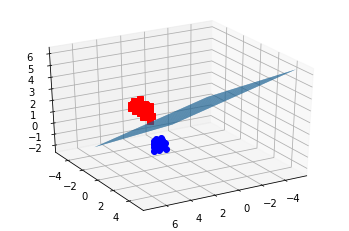

In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from mpl_toolkits.mplot3d import Axes3D
iris = datasets.load_iris()
X = iris.data[:, :3] # we only take the first three features.
Y = iris.target


#make it binary classification problem
X = X[np.logical_or(Y==0,Y==1)]
Y = Y[np.logical_or(Y==0,Y==1)]
model = svm.SVC(kernel='linear')
clf = model.fit(X, Y)
# The equation of the separating plane is given by all x so that np.dot(svc.coef_[0], x) + b = 0.
# Solve for w3 (z)
z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x -clf.coef_[0][1]*y) / clf.coef_[0][2]
tmp = np.linspace(-5,5,30)
x,y = np.meshgrid(tmp,tmp)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(X[Y==0,0], X[Y==0,1], X[Y==0,2],'ob')
ax.plot3D(X[Y==1,0], X[Y==1,1], X[Y==1,2],'sr')
ax.plot_surface(x, y, z(x,y))
ax.view_init(30, 60)
plt.show()


[[1 1]
 [1 5]
 [3 1]
 [3 5]] [0, 0, 1, 1]


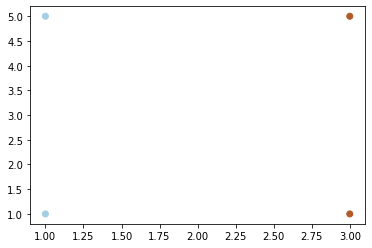

[-1.] 1.0 [-1.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# we create 40 separable points
np.random.seed(0)
X = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
Y = [0] * 20 + [1] * 20

X = np.array([[1,1], [1,5],[3,1],[3,5]])
Y = [0] * 2 + [1] * 2


print(X,Y)
# fit the model
clf = svm.SVC(kernel='linear')
clf.fit(X, Y)

# get the separating hyperplane
w = clf.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-5, 5)
yy = a * xx - (clf.intercept_[0]) / w[1]

# plot the parallels to the separating hyperplane that pass through the
# support vectors
b = clf.support_vectors_[0]
yy_down = a * xx + (b[1] - a * b[0])
b = clf.support_vectors_[-1]
yy_up = a * xx + (b[1] - a * b[0])

# plot the line, the points, and the nearest vectors to the plane
plt.plot(xx, yy, 'k-')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=80, facecolors='none')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)

plt.axis('tight')
plt.show()



y = clf.decision_function([[1,2]])
w_norm = np.linalg.norm(clf.coef_)
dist = y / w_norm
print(y,w_norm,dist)

# haberman

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/haberman-5-1tra.dat', sep=',',skiprows=8, names=['A','B','C','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:3])
z= np.array(df.iloc[:, 3])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/haberman-5-1tst.dat', sep=',',skiprows=8, names=['A','B','C','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:3])
testz= np.array(df.iloc[:, 3])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.6172517188693659
RBF SVM Model 0.6980561921738393
KNN(3-NN) Model 0.636004053136406
Naive Baeyes Model 0.6885544520838639
Decision Tree Model 0.5476517273576097
Bagging Ensemble Model 0.6091068245480009
Random Forest 0.6834181096681097
Gradient Boosting 0.6169711824123588
DES Fault Classification 0.7216738816738817
EKSL 0.6227134793311265
Proposed 0.7051317799847212
C GAMMA 1 0.001953125
Linear SVM Model 0.6162806637806637
RBF SVM Model 0.7534381631440455
KNN(3-NN) Model 0.636004053136406
Naive Baeyes Model 0.6885544520838639
Decision Tree Model 0.5725980392156863
Bagging Ensemble Model 0.593781937017231
Random Forest 0.

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/heart-5-1tra.dat', sep=',',skiprows=18, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:13])
z= np.array(df.iloc[:, 13])
Z=['Class B'  if x==2  else 'Class A' for x in z]

df = pd.read_csv('/content/heart-5-1tst.dat', sep=',',skiprows=18, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:13])
testz= np.array(df.iloc[:, 13])
testZ=['Class B'  if x==2  else 'Class A' for x in testz]

classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.8218799110544281
svm- rbf: 0.0
knn : 0.633841480248036
Naive Bayes : 0.837364053189814
C4.5 : 0.7298389120291493
Bagging : 0.6182374010928406
DES Fault Class : 0.0
EKSL : 0.6226597179091266
G-Mean of the proposed model is 0.41637992631686915
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.8296296296296296
svc-rbf accuracy 0.5555555555555556
knn accuracy 0.6555555555555556
Naive Bayes accuracy 0.8407407407407407
C4.5 accuracy 0.737037037037037
Bagging accuracy 0.6703703703703703
DES Fault Class accuracy 0.5555555555555556
EKSL accuracy 0.6222222222222223
Accuracy Score of the proposed model is 0.5185185185185185
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 0.00048828125
svc accuracy 0.8296296296

KeyboardInterrupt: ignored

# appendicitis

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

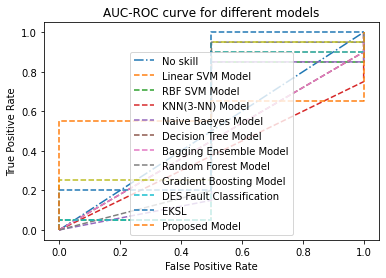

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

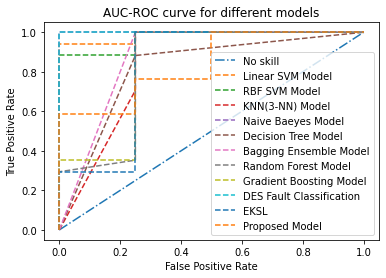

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

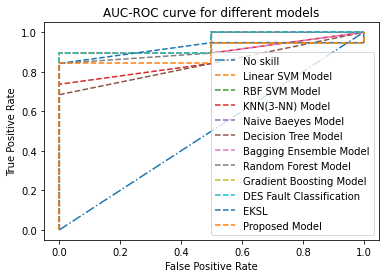

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

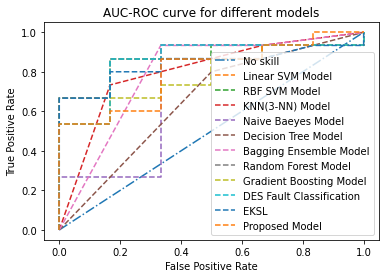

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

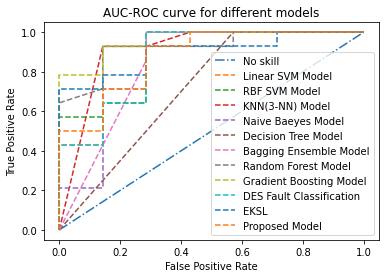

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/appendicitis-5-2tra.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:7])
z= np.array(df.iloc[:, 7])
Z=['Class B'  if x==0  else 'Class A' for x in z]

df = pd.read_csv('/content/appendicitis-5-2tst.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:7])
testz= np.array(df.iloc[:, 7])
testZ=['Class B'  if x==0  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


#banana

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/banana-5-1tra.dat', sep=',',skiprows=7, names=['A','B','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:2])
z= np.array(df.iloc[:, 2])
Z=['Class B'  if x==-1.0  else 'Class A' for x in z]

df = pd.read_csv('/content/banana-5-1tst.dat', sep=',',skiprows=7, names=['A','B','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:2])
testz= np.array(df.iloc[:, 2])
testZ=['Class B'  if x==-1.0  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


FileNotFoundError: ignored

# Ionosphere

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/ionosphere-5-1tra.dat', sep=',',skiprows=38, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','R','S','T','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:33])
z= np.array(df.iloc[:, 33])
Z=['Class B'  if x.replace(' ','')=='g'  else 'Class A' for x in z]


df = pd.read_csv('/content/ionosphere-5-1tst.dat', sep=',',skiprows=38, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','R','S','T','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:33])
testz= np.array(df.iloc[:, 33])
testZ=['Class B'  if x.replace(' ','')=='g'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.8203673922601226
svm- rbf: 0.0
knn : 0.7676087268080579
Naive Bayes : 0.8380350869564899
C4.5 : 0.8611418096742683
Bagging : 0.9137197688171591
DES Fault Class : 0.0
EKSL : 0.3027963536867114
G-Mean of the proposed model is 0.6119177767584059
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.8717505030181087
svc-rbf accuracy 0.6408048289738429
knn accuracy 0.8460764587525151
Naive Bayes accuracy 0.8890140845070423
C4.5 accuracy 0.8688531187122737
Bagging accuracy 0.9402414486921529
DES Fault Class accuracy 0.6408048289738429
EKSL accuracy 0.3019315895372233
Accuracy Score of the proposed model is 0.7035412474849094


KeyboardInterrupt: ignored

# pima

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/pima-5-4tra.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:8])
z= np.array(df.iloc[:, 8])
Z=['Class B'  if x.replace(' ','')=='tested_negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/pima-5-4tst.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:8])
testz= np.array(df.iloc[:, 8])
testZ=['Class B'  if x.replace(' ','')=='tested_negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.8301590339482618
RBF SVM Model 0.7976618209152182
KNN(3-NN) Model 0.735582799194293
Naive Baeyes Model 0.8113716344568926
Decision Tree Model 0.673564255646018
Bagging Ensemble Model 0.732339736743446
Random Forest 0.8205317846634804
Gradient Boosting 0.7794164826081713
DES Fault Classification 0.8319605389023643
EKSL 0.8203032183576653
Proposed 0.6976767690107228


KeyboardInterrupt: ignored

#Sonar

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/sonar-5-2tra.dat', sep=',',skiprows=65, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','BA','BB','BC','BD','BE','BF','BG','BH','BI','BJ','BK','BL','BM','BAA','BAB','BAC','BAD','BAE','BAF','BAG','BAH','BAI','BAJ','BAK','BAL','BAM','BN','BO','BP','BQ','BR','BS','BT','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:60])
z= np.array(df.iloc[:, 60])
Z=['Class B'  if x.replace(' ','')=='R'  else 'Class A' for x in z]


df = pd.read_csv('/content/sonar-5-2tst.dat', sep=',',skiprows=65, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','BA','BB','BC','BD','BE','BF','BG','BH','BI','BJ','BK','BL','BM','BAA','BAB','BAC','BAD','BAE','BAF','BAG','BAH','BAI','BAJ','BAK','BAL','BAM','BN','BO','BP','BQ','BR','BS','BT','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:60])
testz= np.array(df.iloc[:, 60])
testZ=['Class B'  if x.replace(' ','')=='R'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Mounted at /content/gdrive
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.8288081875262183
RBF SVM Model 0.6950927820403523
KNN(3-NN) Model 0.8747683561347243
Naive Baeyes Model 0.7898749746275321
Decision Tree Model 0.7114550399870093
Bagging Ensemble Model 0.8944031313008296
Random Forest 0.9233666084791403
Gradient Boosting 0.9447035954478411
DES Fault Classification 0.8295601090677817
EKSL 0.8922931433442942
Proposed 0.665004066360844


KeyboardInterrupt: ignored

#SpectfHeart

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/spectfheart-5-4tra.dat', sep=',',skiprows=65, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','BA','BB','BC','BD','BE','BF','BG','BH','BI','BJ','BK','BL','BM','BN','BO','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:44])
z= np.array(df.iloc[:, 44])
Z=['Class B'  if x==0  else 'Class A' for x in z]


df = pd.read_csv('/content/spectfheart-5-4tst.dat', sep=',',skiprows=65, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','BA','BB','BC','BD','BE','BF','BG','BH','BI','BJ','BK','BL','BM','BN','BO','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:44])
testz= np.array(df.iloc[:, 44])
testZ=['Class B'  if x==0  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.7842740335000397
RBF SVM Model 0.8335218702865761
KNN(3-NN) Model 0.6907239819004525
Naive Baeyes Model 0.8530172527850546
Decision Tree Model 0.618402860469424
Bagging Ensemble Model 0.6944437829112753
Random Forest 0.8383252626286681
Gradient Boosting 0.7510061919504645
DES Fault Classification 0.779558625069461
EKSL 0.7893314545791326
Proposed 0.7338268370776111
C GAMMA 3.0517578125e-05 0.0001220703125
Linear SVM Model 0.7842740335000397
RBF SVM Model 0.811653568309915
KNN(3-NN) Model 0.6907239819004525
Naive Baeyes Model 0.8530172527850546
Decision Tree Model 0.6178071498504935
Bagging Ensemble Model 0.73070836971765

# Titanic


In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/titanic-5-2tra.dat', sep=',',skiprows=8, names=['A','B','C','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:3])
z= np.array(df.iloc[:, 3])
Z=['Class B'  if x==-1.0  else 'Class A' for x in z]

df = pd.read_csv('/content/titanic-5-2tst.dat', sep=',',skiprows=8, names=['A','B','C','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:3])
testz= np.array(df.iloc[:, 3])
testZ=['Class B'  if x==-1.0 else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.776002886002886
svc-rbf accuracy 0.6769542362399505
knn accuracy 0.7441857349000206
Naive Bayes accuracy 0.7732756132756133
C4.5 accuracy 0.7887250051535767
Bagging accuracy 0.7828159142444857
DES Fault Class accuracy 0.6769542362399505
EKSL accuracy 0.36479694908266336
Accuracy Score of the proposed model is 0.39759121830550403


KeyboardInterrupt: ignored

# wdbc


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.34278838689644464
svm- rbf: 0.0
knn : 0.33052321068157114
Naive Bayes : 0.332262071106971
C4.5 : 0.3481136469492315
Bagging : 0.304145319049837
DES Fault Class : 0.0
EKSL : 0.30594628163328674
G-Mean of the proposed model is 0.30779382083527407
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.9542462350566682
svc-rbf accuracy 0.627278372923459
knn accuracy 0.9314702685918336
Naive Bayes accuracy 0.9366247477099829
C4.5 accuracy 0.9279614966620089
Bagging accuracy 0.9208973761838225
DES Fault Class accuracy 0.627278372923459
EKSL accuracy 0.9244216736531594
Accuracy Score of the proposed model is 0.6786679087098276


No handles with labels found to put in legend.


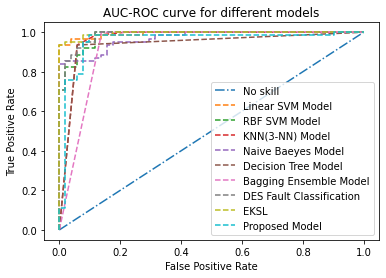




 GMean of Different Models with c and Gamma  3.0517578125e-05 0.0001220703125
svm: 0.34278838689644464
svm- rbf: 0.0
knn : 0.33052321068157114
Naive Bayes : 0.332262071106971
C4.5 : 0.34460487501940695
Bagging : 0.30770066759819903
DES Fault Class : 0.0
EKSL : 0.30594628163328674
G-Mean of the proposed model is 0.3235832945194846


No handles with labels found to put in legend.


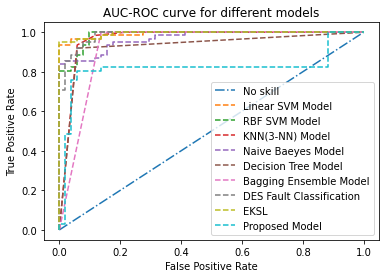




 GMean of Different Models with c and Gamma  3.0517578125e-05 0.00048828125
svm: 0.34278838689644464
svm- rbf: 0.0
knn : 0.33052321068157114
Naive Bayes : 0.332262071106971
C4.5 : 0.34283496351498216
Bagging : 0.30416084458934944
DES Fault Class : 0.0
EKSL : 0.30594628163328674
G-Mean of the proposed model is 0.367458469181804


KeyboardInterrupt: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/wdbc-5-3tra.dat', sep=',',skiprows=35, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:30])
z= np.array(df.iloc[:, 30])
Z=['Class B'  if x.replace(' ','')=='M'  else 'Class A' for x in z]


df = pd.read_csv('/content/wdbc-5-3tst.dat', sep=',',skiprows=35, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','AF','AG','AH','AI','AJ','AK','AL','AM','N','O','P','Q','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:30])
testz= np.array(df.iloc[:, 30])
testZ=['Class B'  if x.replace(' ','')=='M'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

#ecoli

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

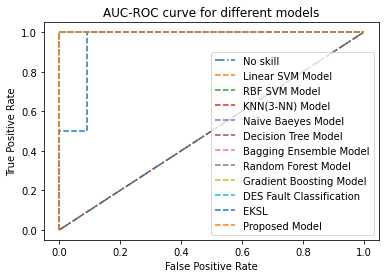

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

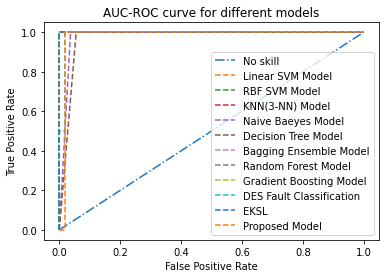

ValueError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/ecoli-0-1-3-7_vs_2-6-5-1tra.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:6])
z= np.array(df.iloc[:, 6])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/ecoli-0-1-3-7_vs_2-6-5-1tst.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:6])
testz= np.array(df.iloc[:, 6])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/ecoli3-5-1tra.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:7])
z= np.array(df.iloc[:, 7])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/ecoli3-5-1tst.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:7])
testz= np.array(df.iloc[:, 7])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.9365631409121619
RBF SVM Model 0.9413950947307088
KNN(3-NN) Model 0.878892459643733
Naive Baeyes Model 0.9092740785501017
Decision Tree Model 0.7772923104828255
Bagging Ensemble Model 0.8857516148547118
Random Forest 0.9311718505338243
Gradient Boosting 0.8939887114662817
DES Fault Classification 0.9366077556005326
EKSL 0.8574625198517243
Proposed 0.8849044619799405
C GAMMA 3.0517578125e-05 0.5
Linear SVM Model 0.9365631409121619
RBF SVM Model 0.9381977335115691
KNN(3-NN) Model 0.878892459643733
Naive Baeyes Model 0.9092740785501017
Decision Tree Model 0.7772923104828255
Bagging Ensemble Model 0.8346804731981976
Random F

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/ecoli2-5-4tra.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:7])
z= np.array(df.iloc[:, 7])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/ecoli2-5-4tst.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:7])
testz= np.array(df.iloc[:, 7])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.7007211219940522
svm- rbf: 0.0
knn : 0.9061861663503683
Naive Bayes : 0.4248029272039616
C4.5 : 0.8526928669504196
Bagging : 0.9261701578494806
DES Fault Class : 0.0
EKSL : 0.11086945847124086
G-Mean of the proposed model is 0.625798570861733
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.904741000877963
svc-rbf accuracy 0.845258999122037
knn accuracy 0.9553116769095699
Naive Bayes accuracy 0.33349429323968394
C4.5 accuracy 0.9046971027216857
Bagging accuracy 0.9672519754170323
DES Fault Class accuracy 0.845258999122037
EKSL accuracy 0.318612818261633
Accuracy Score of the proposed model is 0.642449517120281



 GMean of Different Models with c and Gamma  3.0517578125e-05 0.0001220703125
svm: 0.7007211219940522
svm- 

# glass

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

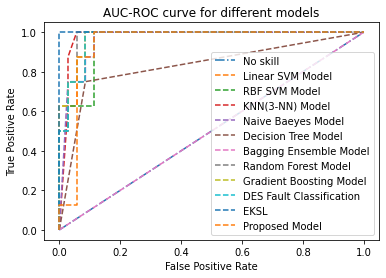

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

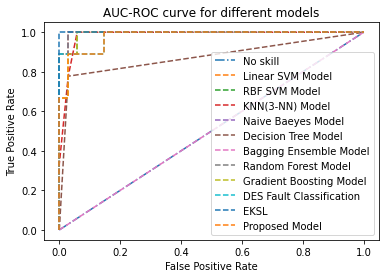

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

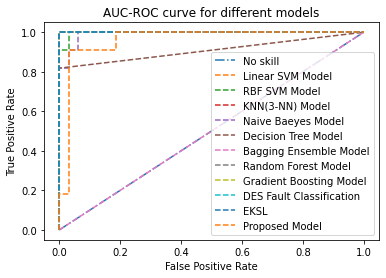

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

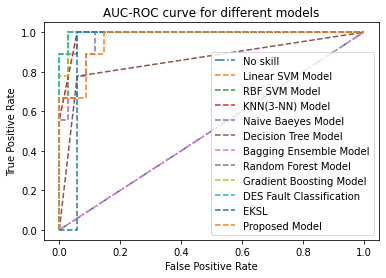

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

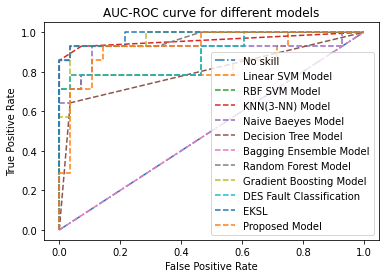

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/glass-0-1-2-3_vs_4-5-6-5-1tra.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:9])
z= np.array(df.iloc[:, 9])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/glass-0-1-2-3_vs_4-5-6-5-1tst.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:9])
testz= np.array(df.iloc[:, 9])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/glass1-5-5tra.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:9])
z= np.array(df.iloc[:, 9])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/glass1-5-5tst.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:9])
testz= np.array(df.iloc[:, 9])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.5282797401306529
RBF SVM Model 0.5203120467167122
KNN(3-NN) Model 0.8609740054288736
Naive Baeyes Model 0.6691824472199726
Decision Tree Model 0.7032641442960916
Bagging Ensemble Model 0.5
Random Forest 0.8777495147779124
Gradient Boosting 0.894039159135508
DES Fault Classification 0.6673250909559226
EKSL 0.7817273906320559
Proposed 0.6911345156984103
C GAMMA 3.0517578125e-05 0.03125
Linear SVM Model 0.6347612216121343
RBF SVM Model 0.748270869503121
KNN(3-NN) Model 0.8609740054288736
Naive Baeyes Model 0.6691824472199726
Decision Tree Model 0.6961808109627583
Bagging Ensemble Model 0.5
Random Forest 0.8777495147779124
G

# shuttle

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/shuttle-6_vs_2-3-5-1tra.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:9])
z= np.array(df.iloc[:, 9])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/shuttle-6_vs_2-3-5-1tst.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:9])
testz= np.array(df.iloc[:, 9])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
3.0517578125e-05 3.0517578125e-05 Linear SVM Model 1.0
3.0517578125e-05 3.0517578125e-05 RBF SVM Model 1.0
3.0517578125e-05 3.0517578125e-05 KNN(3-NN) Model 1.0
3.0517578125e-05 3.0517578125e-05 Naive Baeyes Model 1.0
3.0517578125e-05 3.0517578125e-05 Decision Tree Model 1.0
3.0517578125e-05 3.0517578125e-05 Bagging Ensemble Model 1.0
3.0517578125e-05 3.0517578125e-05 Random Forest 1.0
3.0517578125e-05 3.0517578125e-05 Gradient Boosting 1.0
3.0517578125e-05 3.0517578125e-05 DES Fault Classification 1.0
3.0517578125e-05 3.0517578125e-05 EKSL 1.0
3.0517578125e-05 3.0517578125e-05 Proposed 0.9886363636363636
3.0517578125e-05 0.0001220703125 Linear SVM Model 1.0
3.0517578125e-05 0.000

KeyboardInterrupt: ignored

# iris

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

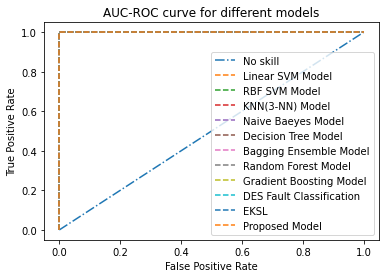

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

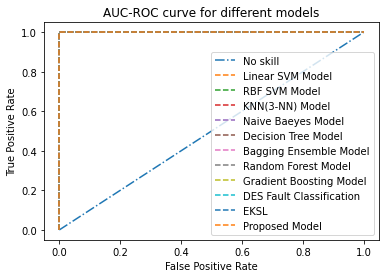

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

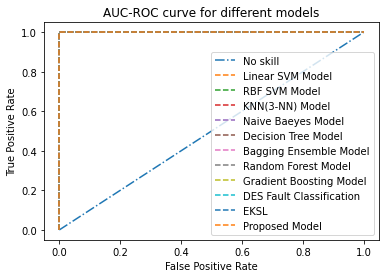

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

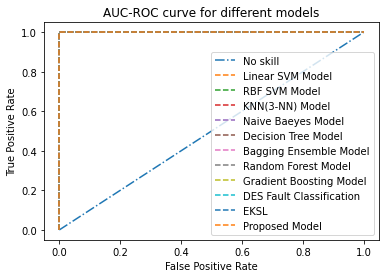

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

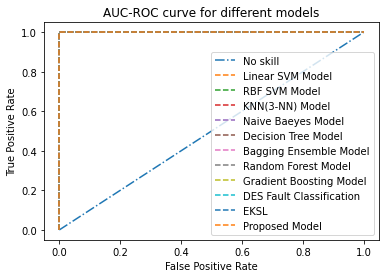

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/iris0-5-1tra.dat', sep=',',skiprows=9, names=['A','B','C','D','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:4])
z= np.array(df.iloc[:, 4])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/iris0-5-1tst.dat', sep=',',skiprows=9, names=['A','B','C','D','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:4])
testz= np.array(df.iloc[:, 4])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


# Thyroid

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

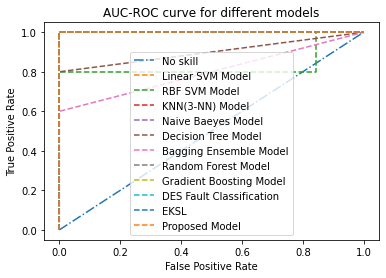

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

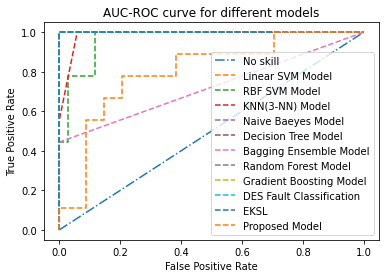

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

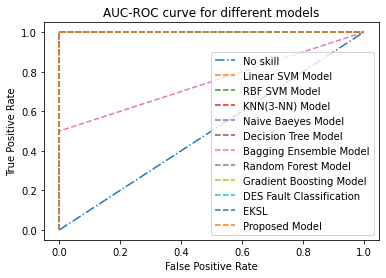

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

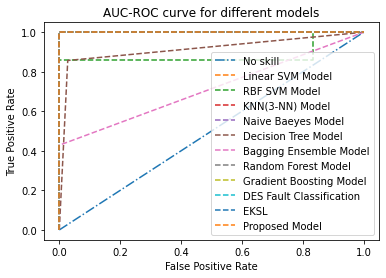

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

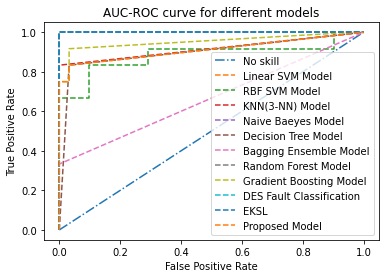

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/new-thyroid1-5-1tra.dat', sep=',',skiprows=10, names=['A','B','C','D','E','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:5])
z= np.array(df.iloc[:, 5])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/new-thyroid1-5-1tst.dat', sep=',',skiprows=10, names=['A','B','C','D','E','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:5])
testz= np.array(df.iloc[:, 5])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/newthyroid2-5-3tra.dat', sep=',',skiprows=10, names=['A','B','C','D','E','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:5])
z= np.array(df.iloc[:, 5])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]

df = pd.read_csv('/content/newthyroid2-5-3tst.dat', sep=',',skiprows=10, names=['A','B','C','D','E','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:5])
testz= np.array(df.iloc[:, 5])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Mounted at /content/gdrive
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.9987179487179487
RBF SVM Model 0.9221067915804756
KNN(3-NN) Model 0.9969715956558062
Naive Baeyes Model 1.0
Decision Tree Model 0.9027822762033288
Bagging Ensemble Model 0.6980586080586081
Random Forest 0.998421052631579
Gradient Boosting 0.9921457489878541
DES Fault Classification 0.9987179487179487
EKSL 1.0
Proposed 0.9433417222890907
C GAMMA 2 0.001953125
Linear SVM Model 0.9987179487179487
RBF SVM Model 1.0
KNN(3-NN) Model 0.9969715956558062
Naive Baeyes Model 1.0
Decision Tree Model 0.924790823211876
Bagging Ensemble Model 0.7303663003663002
Random Forest 0.998421052631579
Gradient Boosting 0.9921457489878541
DES Fault Classification 0.9987179487179487
EKSL 1.0
Proposed 0.9518032607506293
C GAMMA 2 0.0078125
Linear SV

KeyboardInterrupt: ignored

# Vehicle

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/vehicle1-5-2tra.dat', sep=',',skiprows=23, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:18])
z= np.array(df.iloc[:, 18])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]


df = pd.read_csv('/content/vehicle1-5-2tst.dat', sep=',',skiprows=23, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','AA','AB','AC','AD','AE','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:18])
testz= np.array(df.iloc[:, 18])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.7053842449612542
svm- rbf: 0.0
knn : 0.6057861134979751
Naive Bayes : 0.6720309714302
C4.5 : 0.669391698825862
Bagging : 0.0
DES Fault Class : 0.0
EKSL : 0.3288256556647379
G-Mean of the proposed model is 0.44406206335508636
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.8037939436129481
svc-rbf accuracy 0.7435363731291333
knn accuracy 0.730462930734424
Naive Bayes accuracy 0.6926348764357815
C4.5 accuracy 0.7411207796728159
Bagging accuracy 0.7435363731291333
DES Fault Class accuracy 0.7435363731291333
EKSL accuracy 0.35225896275670027
Accuracy Score of the proposed model is 0.5686947441698573


KeyboardInterrupt: ignored

# Wiscosin

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/wisconsin-5-3tra.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:9])
z= np.array(df.iloc[:, 9])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]


df = pd.read_csv('/content/wisconsin-5-3tst.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:9])
testz= np.array(df.iloc[:, 9])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.9951169816232097
RBF SVM Model 0.9953981421459807
KNN(3-NN) Model 0.9858179723139339
Naive Baeyes Model 0.981777139976653
Decision Tree Model 0.9251906463111499
Bagging Ensemble Model 0.977977539632233
Random Forest 0.9907583845439918
Gradient Boosting 0.9910965186662224
DES Fault Classification 0.9949785963417531
EKSL 0.9907553754313458
Proposed 0.976035657066121
C GAMMA 3.0517578125e-05 0.00048828125
Linear SVM Model 0.9951169816232097
RBF SVM Model 0.9954459204546285
KNN(3-NN) Model 0.9858179723139339
Naive Baeyes Model 0.981777139976653
Decision Tree Model 0.9279811640490585
Bagging Ensemble Model 0.9790136925361166


KeyboardInterrupt: ignored

#yeast

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

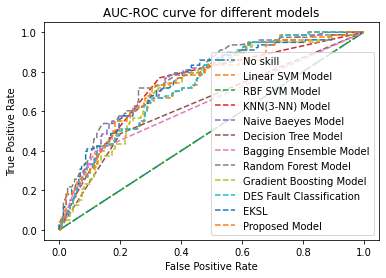

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

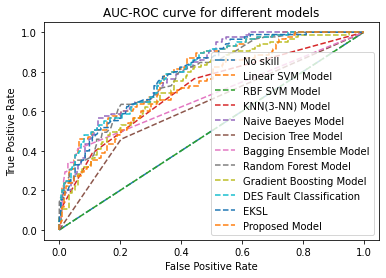

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

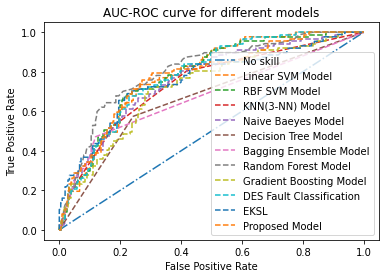

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

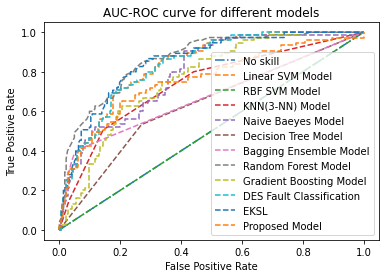

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

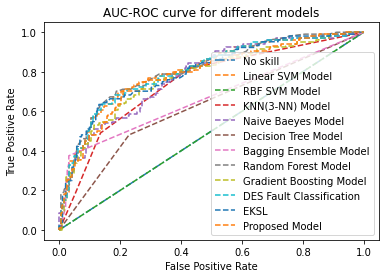

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/yeast1-5-1tra.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:8])
z= np.array(df.iloc[:, 8])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]


df = pd.read_csv('/content/yeast1-5-1tst.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:8])
testz= np.array(df.iloc[:, 8])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/yeast-1_vs_7-5-1tra.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:7])
z= np.array(df.iloc[:, 7])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]


df = pd.read_csv('/content/yeast-1_vs_7-5-1tst.dat', sep=',',skiprows=13, names=['A','B','C','D','E','F','G','H','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:7])
testz= np.array(df.iloc[:, 7])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed
C GAMMA 3.0517578125e-05 3.0517578125e-05
Linear SVM Model 0.8162656304732113
RBF SVM Model 0.7323166363900497
KNN(3-NN) Model 0.7060278707799419
Naive Baeyes Model 0.8087438598206212
Decision Tree Model 0.658480602599716
Bagging Ensemble Model 0.6385823754789272
Random Forest 0.8142747460429955
Gradient Boosting 0.7940422406325776
DES Fault Classification 0.796592319243166
EKSL 0.7644790656880396
Proposed 0.6862930830828384
C GAMMA 3.0517578125e-05 0.0001220703125
Linear SVM Model 0.8158734736104662
RBF SVM Model 0.7657267066915396
KNN(3-NN) Model 0.7060278707799419
Naive Baeyes Model 0.8087438598206212
Decision Tree Model 0.6286766810310885
Bagging Ensemble Model 0.5887198557583

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/shuttle-6_vs_2-3-5-1tra.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:9])
z= np.array(df.iloc[:, 9])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]


df = pd.read_csv('/content/shuttle-6_vs_2-3-5-1tst.dat', sep=',',skiprows=14, names=['A','B','C','D','E','F','G','H','I','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:9])
testz= np.array(df.iloc[:, 9])
testZ=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


ValueError: ignored

#

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/haberman.dat', sep=',',skiprows=8, names=['A','B','C','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:3])
z= np.array(df.iloc[:, 3])
Z=['Class B'  if x.replace(' ','')=='negative'  else 'Class A' for x in z]




classAccuracyForEntireDataset(X,Z)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
the values of c and gamma are 512 0.00048828125
['Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class A', 'Class B', 'Class B', 'Class B', 'Class B', 'Class B', 'Class B', 'Class B', 'Class B', 'Class

# Bupa

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Linear SVM Model RBF SVM Model KNN(3-NN) Model Naive Baeyes Model Decision Tree Model Bagging Ensemble Model Random Forest Gradient Boosting DES Fault Classification EKSL Proposed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

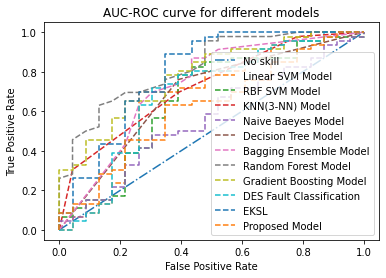

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

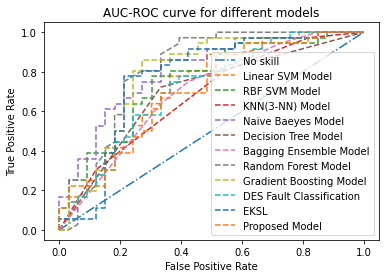

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

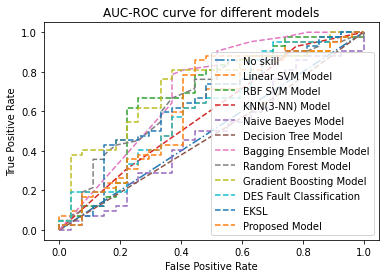

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

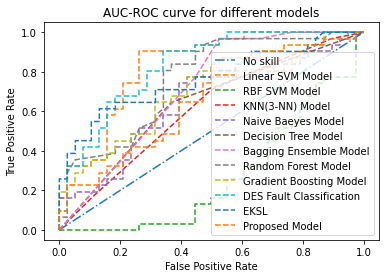

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

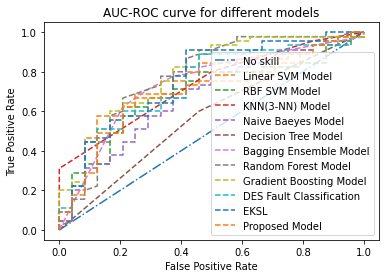

IndexError: ignored

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/bupa-5-1tra.dat', sep=',',skiprows=11, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:6])
z= np.array(df.iloc[:, 6])
Z=['Class B'  if x==2  else 'Class A' for x in z]

df = pd.read_csv('/content/bupa-5-1tst.dat', sep=',',skiprows=11, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:6])
testz= np.array(df.iloc[:, 6])
testZ=['Class B'  if x==2  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


# Monk

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/monk-2-5-5tra.dat', sep=',',skiprows=11, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')

X= np.array(df.iloc[:, 0:6])
z= np.array(df.iloc[:, 6])
Z=['Class B'  if x==1  else 'Class A' for x in z]

df = pd.read_csv('/content/monk-2-5-5tst.dat', sep=',',skiprows=11, names=['A','B','C','D','E','F','Z'])
df.sort_values('Z')
testX= np.array(df.iloc[:, 0:6])
testz= np.array(df.iloc[:, 6])
testZ=['Class B'  if x==1  else 'Class A' for x in testz]


classAccuracyForDataset(X,Z,testX,testZ)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).



 GMean of Different Models with c and Gamma  3.0517578125e-05 3.0517578125e-05
svm: 0.8054337356715212
svm- rbf: 0.0
knn : 0.9842256425734757
Naive Bayes : 0.9200603358746443
C4.5 : 1.0
Bagging : 0.972911179799212
DES Fault Class : 0.0
EKSL : 0.1929745999050295
G-Mean of the proposed model is 0.5023931053128077
Accuracy Score Of Different Models with c and Gamma 3.0517578125e-05 3.0517578125e-05
svc accuracy 0.8057471264367816
svc-rbf accuracy 0.5279337075648223
knn accuracy 0.9838545843357391
Naive Bayes accuracy 0.9191125367548784
C4.5 accuracy 1.0
Bagging accuracy 0.9722534081796311
DES Fault Class accuracy 0.4953755680299385
EKSL accuracy 0.22900294039026997
Accuracy Score of the proposed model is 0.6412189254210104



 GMean of Different Models with c and Gamma  3.0517578125e-05 0.0001220703125
svm: 0.8054337356715212
svm- rbf: 0.0
knn : 0.984225642

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/heart.dat', sep=',',skiprows=18, names=['A','B','C','D','E','F','G','H','I','J','K','L','M','Z'])
df.sort_values('Z')
print(df)

X= np.array(df.iloc[:, 0:13])
z= np.array(df.iloc[:, 13])
Z=['Class B'  if x==1  else 'Class A' for x in z]
print(Z.count('Class A'),Z.count('Class B'))

classAccuracyForEntireDataset(X,Z)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
      A  B  C    D    E  F  G    H  I     J  K  L  M  Z
0    70  1  4  130  322  0  2  109  0  24.0  2  3  3  2
1    67  0  3  115  564  0  2  160  0  16.0  2  0  7  1
2    57  1  2  124  261  0  0  141  0   3.0  1  0  7  2
3    64  1  4  128  263  0  0  105  1   2.0  2  1  7  1
4    74  0  2  120  269  0  2  121  1   2.0  1  1  3  1
..   .. .. ..  ...  ... .. ..  ... ..   ... .. .. .. ..
265  52  1  3  172  199  1  0  162  0   5.0  1  0  7  1
266  44  1  2  120  263  0  0  173  0   0.0  1  0  7  1
267  56  0  2  140  294  0  2  153  0  13.0  2  0  3  1
268  57  1  4  140  192  0  0  148  0   4.0  2  0  6  1
269  67  1  4  160  286  0  2  108  1  15.0  2  3  3  2

[270 rows x 14 columns]
120 150
hello world
[[1, 47, 49, 106, 160, 208], [3, 5, 8, 13, 26, 51, 64, 65, 67, 68, 69, 70, 77, 83, 87, 91, 105, 118, 120, 121, 128, 132, 140, 149, 152, 156, 169, 171, 1

In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/appendicitis-5-2tra.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
df.sort_values('Z')
print(df)

X= np.array(df.iloc[:, 0:7])
z= np.array(df.iloc[:, 7])
Z=['Class B'  if x==0  else 'Class A' for x in z]
print(Z.count('Class A'),Z.count('Class B'))


tdf = pd.read_csv('/content/appendicitis-5-2tst.dat', sep=',',skiprows=12, names=['A','B','C','D','E','F','G','Z'])
tdf.sort_values('Z')
print(tdf)

XY= np.array(tdf.iloc[:, 0:7])
znew= np.array(tdf.iloc[:, 7])
ZZ=['Class B'  if x==0  else 'Class A' for x in znew]



classAccuracyForFoldDataset(X,Z,XY,ZZ)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
        A      B      C      D      E      F      G  Z
0   0.213  0.554  0.207  0.000  0.000  0.749  0.220  1
1   0.458  0.714  0.468  0.111  0.102  0.741  0.436  1
2   0.102  0.518  0.111  0.056  0.022  0.506  0.086  1
3   0.187  0.196  0.105  0.056  0.029  0.133  0.085  1
4   0.116  0.161  0.057  0.333  0.140  0.177  0.049  1
..    ...    ...    ...    ...    ...    ...    ... ..
80  0.449  0.875  0.523  0.083  0.076  0.920  0.487  0
81  0.102  0.000  0.022  0.000  0.000  0.000  0.017  0
82  0.409  0.875  0.482  0.306  0.259  0.914  0.443  0
83  0.427  0.804  0.474  0.056  0.048  0.836  0.437  0
84  0.462  0.911  0.551  0.167  0.154  0.931  0.500  0

[85 rows x 8 columns]
17 68
        A      B      C      D      E      F      G  Z
0   0.236  0.804  0.289  0.111  0.066  0.756  0.241  1
1   0.120  0.250  0.076  0.125  0.053  0.224  0.059  1
2   1.000  0.76

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:191: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  score = y_true == y_pred


In [ ]:
import pandas as pd
import csv
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/monk-2.dat', sep=',',skiprows=11, names=['A','B','C','D','E','H','Z'])
df.sort_values('Z')
print(df)

X= np.array(df.iloc[:, 0:6])
z= np.array(df.iloc[:, 6])
Z=['Class B'  if x==1  else 'Class A' for x in z]
print(Z.count('Class A'),Z.count('Class B'))

classAccuracyForEntireDataset(X,Z)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
     A  B  C  D  E  H  Z
0    1  1  1  1  1  1  1
1    1  1  1  1  1  2  1
2    1  1  1  1  2  2  1
3    1  1  1  1  3  1  1
4    1  1  1  1  3  2  1
..  .. .. .. .. .. .. ..
427  3  2  2  1  2  2  1
428  3  2  2  1  3  2  1
429  3  2  2  1  4  1  0
430  3  2  2  2  4  1  0
431  3  3  1  1  4  2  0

[432 rows x 7 columns]
204 228
[[0, 1, 2, 6, 18, 19, 20, 60, 61, 62, 63, 80, 81, 117, 118, 119, 120, 140, 141, 181, 182, 183, 184, 218, 219, 235, 236, 248, 249, 250, 251, 289, 290, 305, 318, 319, 320, 321], [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 167, 174, 175, 176, 178, 187, 188, 189, 190, 193, 194, 195, 196, 198, 199, 202, 203, 204, 209, 210, 213, 214, 216, 217, 218, 219, 223, 224, 227, 228, 229, 230, 235, 236, 241, 242, 247

In [ ]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

X=[[-0.89947768, -2.3649909,  -0.40437628],
 [-0.91457256,  1.8907955,  -0.27345521],
 [-2.12804621,  0.02010117, -0.74897548],
 [-0.04135051, -0.21210913, -2.63396713],
 [ 2.65899452, -1.85355136, -0.86429554],
 [-3.30992029, -0.74277367,  1.39841572],
 [ 3.78537866,  0.54846409,  1.50778371],
 [ 0.23019648,  0.78321173,  2.40379723],
 [ 1.04083053,  6.29255523,  7.0378829 ],
 [ 4.09487333,  5.66960317,  4.30926055],
 [ 3.33600544,  5.77824007,  5.36364236],
 [ 2.20395889,  2.32941319, 2.5026837 ],
 [ 4.43131246,  3.8663181,   3.67530833],
 [ 5.07961195,  6.64443037,  1.9739586 ],
 [ 3.91400907, 3.65745867,  5.10872099],
 [ 2.77767329,  4.49377292,  0.83321179]]
Y= [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1]
Xtest=[ [-1.51051315,  3.13879011,  0.71605922],
 [-0.61876095, -1.78325954,  0.72846604],
 [ 3.48896967,  3.03145066,  6.56390521],
 [ 4.52318295,  8.08943405,  4.59250376]]
Ytest=[0,0,1,1]
cArr=[pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0),pow(2,1),pow(2,3),pow(2,5),pow(2,7),pow(2,9),pow(2,11),pow(2,13),pow(2,15)]
gammaArr=[pow(2,-15),pow(2,-13),pow(2,-11),pow(2,-9),pow(2,-7),pow(2,-5),pow(2,-3),pow(2,-1),pow(2,0)]

grid_values = {'C':cArr,'gamma':gammaArr}
clf = svm.SVC(kernel='rbf')
grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,scoring = 'recall')
grid_clf_acc.fit(X, Y)
y_pred_acc = grid_clf_acc.predict(Xtest)


# New Model Evaluation metrics
print('Accuracy Score : ' + str(accuracy_score(Ytest,y_pred_acc)))

print(grid_clf_acc.best_params_)

Accuracy Score : 1.0
{'C': 0.5, 'gamma': 0.0078125}
